In [2]:
# Teil 2
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_excel("LoL Ranked Games Master.xlsx")
df.head()

,gameId,gameDuraton,blueWins,blueFirstBlood,blueFirstTower,blueFirstBaron,blueFirstDragon,blueFirstInhibitor,blueDragonKills,blueBaronKills,...,redAssist,redChampionDamageDealt,redTotalGold,redTotalMinionKills,redTotalLevel,redAvgLevel,redJungleMinionKills,redKillingSpree,redTotalHeal,redObjectDamageDealt
0,4227123625,1429,0,1,1,0,0,0,0,0,...,45,53831,41991,609,64,12.8,127,4,12916,26338
1,4219545724,1313,0,0,1,0,0,0,0,0,...,43,52924,39672,510,63,12.6,133,4,12252,29828
2,4219463634,1660,1,0,0,1,1,1,1,1,...,22,61745,46516,630,65,13.0,153,2,17005,37066
3,4205778093,984,1,1,1,0,1,0,2,0,...,5,25007,21444,304,41,8.2,51,1,10499,3085
4,4201063474,1437,0,1,1,0,1,0,2,0,...,39,71794,45798,565,68,13.6,150,7,47523,47150


In [6]:
# Informationen über den Datensatz

print("Form des Datensatzes:")
print(df.shape)

print("\nInformationen zu den Spalten:")
df.info()


Form des Datensatzes:
(98999, 49)

Informationen zu den Spalten:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98999 entries, 0 to 98998
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gameId                   98999 non-null  int64  
 1   gameDuraton              98999 non-null  int64  
 2   blueWins                 98999 non-null  int64  
 3   blueFirstBlood           98999 non-null  int64  
 4   blueFirstTower           98999 non-null  int64  
 5   blueFirstBaron           98999 non-null  int64  
 6   blueFirstDragon          98999 non-null  int64  
 7   blueFirstInhibitor       98999 non-null  int64  
 8   blueDragonKills          98999 non-null  int64  
 9   blueBaronKills           98999 non-null  int64  
 10  blueTowerKills           98999 non-null  int64  
 11  blueInhibitorKills       98999 non-null  int64  
 12  blueWardPlaced           98999 non-null  int64  
 13  blueWardkil

In [7]:
# Fehlende Werte anzeigen

df.isnull().sum()

gameId                     0
gameDuraton                0
blueWins                   0
blueFirstBlood             0
blueFirstTower             0
blueFirstBaron             0
blueFirstDragon            0
blueFirstInhibitor         0
blueDragonKills            0
blueBaronKills             0
blueTowerKills             0
blueInhibitorKills         0
blueWardPlaced             0
blueWardkills              0
blueKills                  0
blueDeath                  0
blueAssist                 0
blueChampionDamageDealt    0
blueTotalGold              0
blueTotalMinionKills       0
blueTotalLevel             0
blueAvgLevel               0
blueJungleMinionKills      0
blueKillingSpree           0
blueTotalHeal              0
blueObjectDamageDealt      0
redFirstBlood              0
redFirstTower              0
redFirstBaron              0
redFirstDragon             0
redFirstInhibitor          0
redDragonKills             0
redBaronKills              0
redTowerKills              0
redInhibitorKi

In [8]:
# Zielvariable definieren

target = "blueWins"

print("Gewählte Zielvariable:", target)

Gewählte Zielvariable: blueWins


In [9]:
# Statistische Übersicht über den gesamten Datensatz

df.describe()

,gameId,gameDuraton,blueWins,blueFirstBlood,blueFirstTower,blueFirstBaron,blueFirstDragon,blueFirstInhibitor,blueDragonKills,blueBaronKills,...,redAssist,redChampionDamageDealt,redTotalGold,redTotalMinionKills,redTotalLevel,redAvgLevel,redJungleMinionKills,redKillingSpree,redTotalHeal,redObjectDamageDealt
count,9.899900e+04,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,...,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000
mean,4.162011e+09,1433.322266,0.494732,0.507147,0.513106,0.236134,0.408257,0.386994,1.359872,0.296993,...,39.746018,68710.416752,47843.560864,501.697189,64.677290,12.935458,125.623501,5.675583,24553.922201,36941.415418
std,1.009908e+08,436.532535,0.499975,0.499951,0.499831,0.424707,0.491514,0.487065,1.256221,0.535511,...,28.720222,37599.297575,16431.420338,180.015340,15.157568,3.031514,66.681999,3.627958,15504.881388,27039.107222
min,3.163679e+09,190.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.133528e+09,1121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19.000000,40474.000000,36136.000000,383.000000,55.000000,11.000000,84.000000,3.000000,13286.000000,12644.000000
50%,4.192271e+09,1420.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,35.000000,63813.000000,47936.000000,518.000000,66.000000,13.200000,128.000000,5.000000,21480.000000,32593.000000
75%,4.223966e+09,1736.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,2.000000,1.000000,...,53.000000,90415.000000,59086.000000,627.000000,75.000000,15.000000,172.000000,8.000000,32375.000000,57401.000000
max,4.257322e+09,3758.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,4.000000,...,225.000000,341957.000000,141692.000000,1338.000000,145.000000,29.000000,488.000000,29.000000,188817.000000,191193.000000


In [12]:
# Statistische Werte für einige wichtige Spalten

wichtige_spalten = [
    "blueKills",
    "blueTotalGold",
    "blueTotalLevel",
    "blueDragonKills",
    "blueTowerKills"
]

df[wichtige_spalten].describe()

,blueKills,blueTotalGold,blueTotalLevel,blueDragonKills,blueTowerKills
count,98999.000000,98999.000000,98999.000000,98999.000000,98999.000000
mean,24.685209,47716.270892,64.465651,1.359872,4.341640
std,13.577869,16212.697901,14.992167,1.256221,3.400012
min,0.000000,3355.000000,5.000000,0.000000,0.000000
25%,15.000000,36206.500000,55.000000,0.000000,1.000000
50%,24.000000,47703.000000,65.000000,1.000000,4.000000
75%,33.000000,58732.000000,75.000000,2.000000,7.000000
max,112.000000,134323.000000,134.000000,7.000000,11.000000


In [13]:
# Median und Standardabweichung berechnen

for spalte in wichtige_spalten:
    print("Spalte:", spalte)
    print("Median:", df[spalte].median())
    print("Standardabweichung:", df[spalte].std())
    print()

Spalte: blueKills
Median: 24.0
Standardabweichung: 13.577869162541718

Spalte: blueTotalGold
Median: 47703.0
Standardabweichung: 16212.697901357562

Spalte: blueTotalLevel
Median: 65.0
Standardabweichung: 14.992167139034045

Spalte: blueDragonKills
Median: 1.0
Standardabweichung: 1.2562208234419336

Spalte: blueTowerKills
Median: 4.0
Standardabweichung: 3.4000121484597674



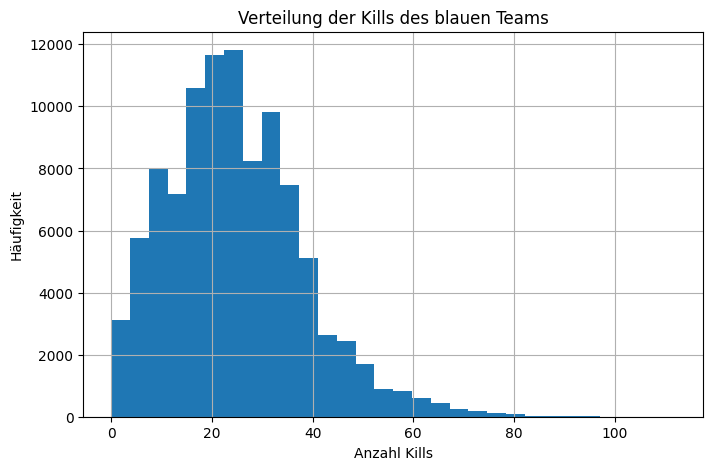

In [14]:
# Histogramm erstellen

plt.figure(figsize=(8,5))

df["blueKills"].hist(bins=30)

plt.title("Verteilung der Kills des blauen Teams")
plt.xlabel("Anzahl Kills")
plt.ylabel("Häufigkeit")

plt.show()

In [15]:
# Skalierung eines Datenfeldes

scaler = StandardScaler()

df["blueTotalGold_scaled"] = scaler.fit_transform(df[["blueTotalGold"]])

df[["blueTotalGold", "blueTotalGold_scaled"]].head()

,blueTotalGold,blueTotalGold_scaled
0,41910,-0.358133
1,35880,-0.730065
2,58214,0.647504
3,36545,-0.689048
4,42395,-0.328218
